# Doprinos 2 — Analiza otpornosti Faster-Whisper modela na beli i pink šum pri različitim SNR nivoima

## Cilj eksperimenta

Cilj eksperimenta je ispitivanje otpornosti Faster-Whisper modela na prisustvo pozadinskog šuma različitog intenziteta.

Za evaluaciju je odabrano 10 prirodnih srpskih audio zapisa iz glavnog benchmark skupa, koji obuhvataju sva tri govornika i različite dužine snimaka. Za svaki originalni zapis generisane su verzije sa belim i pink šumom pri SNR nivoima **20, 10, 5, 0, -5, -10 i -15 dB**.

U svim testovima koristi se Faster-Whisper `base` model sa INT8 kvantizacijom na CPU-u. Na taj način model i parametri transkripcije ostaju nepromenjeni, dok se menjaju samo tip i intenzitet šuma, što omogućava direktnu analizu njihovog uticaja na tačnost transkripcije.


In [1]:
from pathlib import Path
import re
import time

import numpy as np
import pandas as pd
import soundfile as sf
import colorednoise as cn
import matplotlib.pyplot as plt

from faster_whisper import WhisperModel
from jiwer import wer


# ============================================================
# PUTANJE
# ============================================================

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

AUDIO_DIR = PROJECT_ROOT / "audio" / "40Sentences00-08Notebooks"

SNR_DIR = PROJECT_ROOT / "audio" / "snr_test_10sr"

REZULTATI_DIR = PROJECT_ROOT / "rezultati" / "02_otpornost_na_sum_snr"

SNR_DIR.mkdir(parents=True, exist_ok=True)
REZULTATI_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("AUDIO_DIR:", AUDIO_DIR)
print("SNR_DIR:", SNR_DIR)
print("REZULTATI_DIR:", REZULTATI_DIR)

PROJECT_ROOT: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR
AUDIO_DIR: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\audio\40Sentences00-08Notebooks
SNR_DIR: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\audio\snr_test_10sr
REZULTATI_DIR: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\rezultati\02_otpornost_na_sum_snr


In [2]:
# ============================================================
# TEST SKUP — 10 PRIRODNIH SRPSKIH SNIMAKA
# ============================================================

# Izabrani fajlovi:
# 2, 6, 9, 12, 17, 22, 27, 32, 36, 39
#
# Obuhvaćeni su svi govornici i sve grupe dužine.

test_set = [
    {
        "broj": 2,
        "audio": AUDIO_DIR / "2govornik1.wav",
        "govornik": "govornik1",
        "grupa": "kratki",
        "ref": "Automatsko prepoznavanje govora pretvara izgovorene reči u tekst koji računar može dalje da obrađuje."
    },
    {
        "broj": 6,
        "audio": AUDIO_DIR / "6govornik2.wav",
        "govornik": "govornik2",
        "grupa": "kratki",
        "ref": "Sutra ujutru moram da završim nekoliko obaveza, a zatim planiram da se vidim sa prijateljima."
    },
    {
        "broj": 9,
        "audio": AUDIO_DIR / "9govornik3.wav",
        "govornik": "govornik3",
        "grupa": "kratki",
        "ref": "Neuronske mreže danas se koriste za obradu slike, teksta, zvuka i mnogih drugih vrsta podataka."
    },
    {
        "broj": 12,
        "audio": AUDIO_DIR / "12govornik1.wav",
        "govornik": "govornik1",
        "grupa": "srednji",
        "ref": "Juče sam krenuo do grada nešto ranije nego obično. Na ulicama nije bilo mnogo ljudi, pa sam brzo završio sve obaveze. Nakon toga sam seo u obližnji kafić i sačekao prijatelja."
    },
    {
        "broj": 17,
        "audio": AUDIO_DIR / "17govornik2.wav",
        "govornik": "govornik2",
        "grupa": "srednji",
        "ref": "Veći modeli mašinskog učenja često mogu da postignu veću tačnost, ali zahtevaju više memorije i procesorske snage. Zbog toga najveći model nije uvek najbolji izbor za praktičnu primenu."
    },
    {
        "broj": 22,
        "audio": AUDIO_DIR / "22govornik3.wav",
        "govornik": "govornik3",
        "grupa": "srednji",
        "ref": "Čovek tokom običnog razgovora često pravi kratke pauze, menja brzinu govora ili zastane kako bi razmislio. Sistem za prepoznavanje govora mora da bude dovoljno robustan da pravilno obradi takve situacije."
    },
    {
        "broj": 27,
        "audio": AUDIO_DIR / "27govornik1.wav",
        "govornik": "govornik1",
        "grupa": "dugi",
        "ref": "Jednog jutra krenuo sam automobilom prema gradu nešto ranije nego obično. Saobraćaj je u početku bio veoma slab, ali se približavanjem centru broj vozila postepeno povećavao. Dok sam čekao na semaforu, na radiju su govorili o vremenskoj prognozi za narednih nekoliko dana. Najavljeno je sunčano vreme, ali i mogućnost kratkotrajne kiše tokom vikenda. Kada sam stigao, parkirao sam automobil i nastavio pešice."
    },
    {
        "broj": 32,
        "audio": AUDIO_DIR / "32govornik3.wav",
        "govornik": "govornik3",
        "grupa": "dugi",
        "ref": "Ljudski govor nije potpuno konstantan signal. Neko govori brzo, neko sporije, a pojedini govornici prave veoma duge pauze između rečenica. Razlikuju se i visina glasa, naglasak, način izgovora i jačina govora. Sistem koji postiže odlične rezultate kod jednog govornika zato ne mora nužno da postigne iste rezultate kod druge osobe. Korišćenje više govornika omogućava realniju procenu sposobnosti modela da generalizuje."
    },
    {
        "broj": 36,
        "audio": AUDIO_DIR / "36govornik1.wav",
        "govornik": "govornik1",
        "grupa": "veoma_dugi",
        "ref": "Savremeni sistemi za automatsko prepoznavanje govora imaju veliki broj praktičnih primena. Mogu se koristiti za automatsko pravljenje transkripata sastanaka, generisanje titlova, glasovne asistente, pretragu multimedijalnog sadržaja i poboljšanje pristupačnosti digitalnih sistema. Ipak, kvalitet njihovog rada zavisi od velikog broja faktora. Govornici imaju različite glasove, akcente i brzine govora, dok snimci mogu nastati korišćenjem različitih mikrofona i u različitim prostorijama. Dodatni problem predstavlja pozadinski šum. Sistem koji veoma dobro radi u tihoj prostoriji ne mora da postigne isti rezultat na ulici ili u automobilu. Zbog toga evaluacija sistema ne bi trebalo da bude zasnovana na samo jednom zvučnom zapisu. Potrebno je koristiti više govornika, različite dužine snimaka i različite uslove. Pored tačnosti transkripcije, važno je analizirati vreme izvršavanja, potrošnju memorije i sposobnost sistema da obrađuje zvuk dovoljno brzo za praktičnu primenu."
    },
    {
        "broj": 39,
        "audio": AUDIO_DIR / "39govornik3.wav",
        "govornik": "govornik3",
        "grupa": "veoma_dugi",
        "ref": "Sistem koji obrađuje govor u realnom vremenu mora da rešava nešto drugačiji problem od sistema koji dobije kompletan audio zapis. Kod klasične transkripcije model može da dobije čitav snimak i zatim ga obradi. Kod realnog vremena zvuk neprestano pristiže, pa ga je potrebno podeliti na manje delove. Ako koristimo veoma kratke segmente, sistem može brzo da prikaže rezultat, ali model ima manje konteksta za pravilno prepoznavanje rečenice. Sa druge strane, ako koristimo duge segmente, model dobija više konteksta, ali korisnik mora duže da čeka na rezultat. Zbog toga izbor veličine segmenta predstavlja kompromis između latencije i kvaliteta transkripcije. Na primer, mogu se uporediti segmenti od dve, pet i deset sekundi. Za svaku konfiguraciju moguće je izmeriti vreme obrade, faktor realnog vremena i tačnost konačnog transkripta. Takav eksperiment omogućava da se utvrdi koja konfiguracija predstavlja najbolji kompromis za praktičan sistem."
    }
]


# Provera postojanja svih fajlova

for item in test_set:
    if not item["audio"].exists():
        raise FileNotFoundError(
            f"Audio fajl nije pronađen: {item['audio']}"
        )

print(f"Sva {len(test_set)} audio fajla su pronađena.")

Sva 10 audio fajla su pronađena.


In [3]:
# ============================================================
# NORMALIZACIJA TEKSTA I WER
# ============================================================

def normalizuj_tekst(tekst):
    tekst = tekst.lower().strip()

    tekst = re.sub(
        r"[^\w\sčćžšđ]",
        " ",
        tekst,
        flags=re.UNICODE
    )

    tekst = re.sub(
        r"\s+",
        " ",
        tekst
    ).strip()

    return tekst


def izracunaj_wer(referenca, hipoteza):
    return wer(
        normalizuj_tekst(referenca),
        normalizuj_tekst(hipoteza)
    )

In [4]:
# ============================================================
# FUNKCIJA ZA DODAVANJE ŠUMA SA DEFINISANIM SNR-om
# ============================================================

def dodaj_sum_snr(signal, noise, snr_db):

    signal = signal.astype(np.float64)
    noise = noise.astype(np.float64)

    signal_power = np.mean(signal ** 2)
    noise_power = np.mean(noise ** 2)

    if signal_power == 0:
        raise ValueError("Signal ima nultu snagu.")

    if noise_power == 0:
        raise ValueError("Šum ima nultu snagu.")

    target_noise_power = (
        signal_power / (10 ** (snr_db / 10.0))
    )

    noise_scaled = noise * np.sqrt(
        target_noise_power / noise_power
    )

    noisy_signal = signal + noise_scaled

    # Sprečavanje clipping-a.
    # Skalira se cela mešavina, pa SNR ostaje nepromenjen.

    peak = np.max(np.abs(noisy_signal))

    if peak > 0.999:
        noisy_signal = noisy_signal * (0.999 / peak)

    return noisy_signal.astype(np.float32)

## Generisanje test signala sa šumom

Šum se dodaje tako da se za svaki audio zapis postigne unapred definisan odnos signal-šum (SNR). Veća SNR vrednost označava dominantniji govorni signal i blaži šum, dok negativne SNR vrednosti predstavljaju uslove u kojima šum postaje snažniji od korisnog govornog signala.

Testiraju se dve vrste šuma. Beli šum ima energiju raspoređenu kroz širok frekvencijski opseg, dok pink šum ima drugačiju spektralnu raspodelu sa izraženijim nižim frekvencijama. Time se ispituje da li na model, pored intenziteta, utiče i spektralna karakteristika šuma.

Za sprečavanje clipping-a kompletna mešavina signala i šuma po potrebi se proporcionalno skalira, čime se zadržava prethodno definisan SNR odnos. Fiksiranjem slučajnog seed-a omogućena je reproduktivnost generisanih test signala.


In [5]:
# ============================================================
# GENERISANJE BELIH I PINK ŠUMOVA
# ============================================================

snr_vrednosti = [
    20,
    10,
    5,
    0,
    -5,
    -10,
    -15
]

tipovi_suma = [
    "beli",
    "pink"
]


# Fiksni seed radi reproduktivnosti rezultata

rng = np.random.default_rng(42)
np.random.seed(42)


generisani_fajlovi = []


for item in test_set:

    audio, sr = sf.read(
        item["audio"],
        dtype="float32"
    )

    # Stereo -> mono

    if audio.ndim > 1:
        audio = audio.mean(axis=1)

    if np.max(np.abs(audio)) == 0:
        raise ValueError(
            f"Prazan audio signal: {item['audio']}"
        )


    for snr_db in snr_vrednosti:

        for naziv_suma in tipovi_suma:

            if naziv_suma == "beli":

                noise = rng.normal(
                    0,
                    1,
                    len(audio)
                )

            else:

                noise = cn.powerlaw_psd_gaussian(
                    1,
                    len(audio)
                )


            audio_sum = dodaj_sum_snr(
                audio,
                noise,
                snr_db
            )


            naziv_fajla = (
                f"{item['broj']:02d}_"
                f"{item['govornik']}_"
                f"{naziv_suma}_"
                f"{snr_db}db.wav"
            )


            izlazna_putanja = SNR_DIR / naziv_fajla


            sf.write(
                izlazna_putanja,
                audio_sum,
                sr
            )


            generisani_fajlovi.append({
                "Broj": item["broj"],
                "Govornik": item["govornik"],
                "Tip šuma": naziv_suma,
                "SNR [dB]": snr_db,
                "Putanja": str(izlazna_putanja)
            })


print(
    f"Generisano noisy fajlova: {len(generisani_fajlovi)}"
)

print(
    "Očekivano:",
    len(test_set) * len(snr_vrednosti) * len(tipovi_suma)
)

Generisano noisy fajlova: 140
Očekivano: 140


## Eksperimentalni skup

Za 10 originalnih audio zapisa generisano je ukupno **140 verzija sa šumom**: dva tipa šuma × sedam SNR nivoa × deset originalnih snimaka.

Zajedno sa 10 originalnih clean verzija, model se evaluira na ukupno **150 test slučajeva**. Ovakva organizacija omogućava da se za svaki originalni snimak direktno prati promena kvaliteta transkripcije sa postepenim povećavanjem intenziteta šuma.


In [6]:
# ============================================================
# FASTER-WHISPER MODEL
# ============================================================

model = WhisperModel(
    "base",
    device="cpu",
    compute_type="int8"
)

print("Faster-Whisper base INT8 je učitan.")

Faster-Whisper base INT8 je učitan.


In [7]:
# ============================================================
# GLAVNI EKSPERIMENT — CLEAN + NOISY AUDIO
# ============================================================

rezultati = []


for indeks, item in enumerate(test_set, start=1):

    ref = item["ref"]
    originalni_fajl = item["audio"]


    print("\n" + "=" * 100)

    print(
        f"[{indeks:02d}/{len(test_set)}] "
        f"{originalni_fajl.name}"
    )

    print("=" * 100)


    # ========================================================
    # CLEAN SIGNAL
    # ========================================================

    start = time.perf_counter()


    segments, info = model.transcribe(
        str(originalni_fajl),
        language="sr"
    )


    tekst_clean = " ".join(
        segment.text.strip()
        for segment in segments
    ).strip()


    vreme_clean = time.perf_counter() - start


    wer_clean = izracunaj_wer(
        ref,
        tekst_clean
    )


    rezultati.append({
        "Broj": item["broj"],
        "Audio ID": originalni_fajl.name,
        "Govornik": item["govornik"],
        "Grupa_duzine": item["grupa"],
        "Tip šuma": "bez šuma",
        "SNR [dB]": np.inf,
        "WER": round(wer_clean, 4),
        "WER [%]": round(wer_clean * 100, 2),
        "Vreme [s]": round(vreme_clean, 3),
        "Transkripcija": tekst_clean
    })


    print(
        f"CLEAN        | "
        f"WER {wer_clean * 100:6.2f}% | "
        f"{vreme_clean:6.2f} s"
    )


    # ========================================================
    # NOISY SIGNALI
    # ========================================================

    for snr_db in snr_vrednosti:

        for naziv_suma in tipovi_suma:


            naziv_fajla = (
                f"{item['broj']:02d}_"
                f"{item['govornik']}_"
                f"{naziv_suma}_"
                f"{snr_db}db.wav"
            )


            putanja = SNR_DIR / naziv_fajla


            start = time.perf_counter()


            segments, info = model.transcribe(
                str(putanja),
                language="sr"
            )


            tekst_sum = " ".join(
                segment.text.strip()
                for segment in segments
            ).strip()


            vreme = time.perf_counter() - start


            greska = izracunaj_wer(
                ref,
                tekst_sum
            )


            rezultati.append({
                "Broj": item["broj"],
                "Audio ID": originalni_fajl.name,
                "Govornik": item["govornik"],
                "Grupa_duzine": item["grupa"],
                "Tip šuma": naziv_suma,
                "SNR [dB]": snr_db,
                "WER": round(greska, 4),
                "WER [%]": round(greska * 100, 2),
                "Vreme [s]": round(vreme, 3),
                "Transkripcija": tekst_sum
            })


            print(
                f"{naziv_suma:<5} "
                f"{snr_db:>3} dB | "
                f"WER {greska * 100:6.2f}% | "
                f"{vreme:6.2f} s"
            )


tabela_snr = pd.DataFrame(rezultati)


print(
    "\nUkupan broj test slučajeva:",
    len(tabela_snr)
)

display(tabela_snr.head(20))


[01/10] 2govornik1.wav
CLEAN        | WER  35.71% |   1.24 s
beli   20 dB | WER  35.71% |   1.20 s
pink   20 dB | WER  42.86% |   1.25 s
beli   10 dB | WER  71.43% |   1.25 s
pink   10 dB | WER  71.43% |   1.25 s
beli    5 dB | WER  85.71% |   1.19 s
pink    5 dB | WER  78.57% |   1.27 s
beli    0 dB | WER  57.14% |   1.36 s
pink    0 dB | WER  78.57% |   1.24 s
beli   -5 dB | WER 107.14% |   1.28 s
pink   -5 dB | WER 100.00% |  13.19 s
beli  -10 dB | WER 100.00% |   1.97 s
pink  -10 dB | WER 107.14% |   9.13 s
beli  -15 dB | WER 100.00% |   7.99 s
pink  -15 dB | WER 100.00% |   0.88 s

[02/10] 6govornik2.wav
CLEAN        | WER  33.33% |   1.15 s
beli   20 dB | WER  40.00% |   1.17 s
pink   20 dB | WER  26.67% |   1.17 s
beli   10 dB | WER  33.33% |   1.15 s
pink   10 dB | WER  40.00% |   1.17 s
beli    5 dB | WER  33.33% |   1.14 s
pink    5 dB | WER  40.00% |   1.16 s
beli    0 dB | WER 106.67% |   5.47 s
pink    0 dB | WER  93.33% |   1.16 s
beli   -5 dB | WER  93.33% |   5.40 s
pi

,Broj,Audio ID,Govornik,Grupa_duzine,Tip šuma,SNR [dB],WER,WER [%],Vreme [s],Transkripcija
0,2,2govornik1.wav,govornik1,kratki,bez šuma,inf,0.3571,35.71,1.236,"Automacko prepoznamenje govora, pretvara izgov..."
1,2,2govornik1.wav,govornik1,kratki,beli,20.0,0.3571,35.71,1.199,"Automacko prepoznamenje govora, pretvara izgov..."
2,2,2govornik1.wav,govornik1,kratki,pink,20.0,0.4286,42.86,1.251,"Automacko prepoznamenje govora, pretvara izgov..."
3,2,2govornik1.wav,govornik1,kratki,beli,10.0,0.7143,71.43,1.249,"Automacko prepoznamenje govora, pretverej zgov..."
4,2,2govornik1.wav,govornik1,kratki,pink,10.0,0.7143,71.43,1.246,"Automacko prepoznamenje govora, dretveraj zgov..."
5,2,2govornik1.wav,govornik1,kratki,beli,5.0,0.8571,85.71,1.186,"Automacko prepoznamenje govora, redfaraj s gov..."
6,2,2govornik1.wav,govornik1,kratki,pink,5.0,0.7857,78.57,1.265,"Automacko prepoznamenje govora, pretvere zgovo..."
7,2,2govornik1.wav,govornik1,kratki,beli,0.0,0.5714,57.14,1.359,"Automatsko prepoznamen je govora, pretvara je ..."
8,2,2govornik1.wav,govornik1,kratki,pink,0.0,0.7857,78.57,1.237,"Automatske prepoznamenji govora, retrorej zdov..."
9,2,2govornik1.wav,govornik1,kratki,beli,-5.0,1.0714,107.14,1.283,"Automatski preko znamo mi dovora, pretvara izg..."


In [8]:
# ============================================================
# PROSEČAN CLEAN WER
# ============================================================

clean = tabela_snr[
    tabela_snr["Tip šuma"] == "bez šuma"
].copy()


clean_prosek = clean["WER [%]"].mean()


print(
    f"Prosečan CLEAN WER: {clean_prosek:.2f}%"
)

Prosečan CLEAN WER: 47.89%


In [9]:
# ============================================================
# PROSEČAN WER PO SNR NIVOU I TIPU ŠUMA
# ============================================================

tabela_noisy = tabela_snr[
    tabela_snr["Tip šuma"] != "bez šuma"
].copy()


tabela_prosek = (
    tabela_noisy
    .groupby([
        "Tip šuma",
        "SNR [dB]"
    ])
    .agg(
        Broj_testova=("Audio ID", "count"),
        Prosecan_WER=("WER [%]", "mean"),
        Medijana_WER=("WER [%]", "median"),
        Prosecno_vreme=("Vreme [s]", "mean")
    )
    .reset_index()
    .round(3)
)


print(
    "PROSEČNI REZULTATI PO TIPU ŠUMA I SNR NIVOU"
)

display(tabela_prosek)

PROSEČNI REZULTATI PO TIPU ŠUMA I SNR NIVOU


,Tip šuma,SNR [dB],Broj_testova,Prosecan_WER,Medijana_WER,Prosecno_vreme
0,beli,-15.0,10,100.667,100.000,19.342
1,beli,-10.0,10,115.335,114.810,21.104
2,beli,-5.0,10,95.856,93.330,19.862
3,beli,0.0,10,82.741,83.335,7.374
4,beli,5.0,10,65.844,65.025,3.955
5,beli,10.0,10,58.752,64.270,3.994
6,beli,20.0,10,48.162,52.415,3.974
7,pink,-15.0,10,99.320,100.000,10.974
8,pink,-10.0,10,104.560,100.000,25.056
9,pink,-5.0,10,101.763,101.615,19.976


## Analiza uticaja SNR nivoa na WER

Rezultati pokazuju jasnu degradaciju kvaliteta transkripcije sa smanjivanjem SNR vrednosti. Prosečan WER na originalnim snimcima bez dodatog šuma iznosi **47,89%**.

Pri SNR-u od **20 dB**, gde je govor i dalje dominantan u odnosu na šum, prosečan WER iznosi **48,16%** za beli i **50,71%** za pink šum, što predstavlja relativno malu promenu u odnosu na clean signal.

Sa povećanjem intenziteta šuma degradacija postaje izraženija. Pri **10 dB** WER raste na **58,75%** za beli i **59,06%** za pink šum, dok pri **5 dB** dostiže **65,84%** odnosno **63,38%**.

Posebno izraženo pogoršanje javlja se pri **0 dB**, kada signal i šum imaju približno jednaku snagu. Prosečan WER tada raste na **82,74%** za beli i **82,70%** za pink šum.

U negativnom SNR području dolazi do veoma ozbiljne degradacije transkripcije. Pri **-5 dB** prosečan WER iznosi **95,86%** za beli i **101,76%** za pink šum, dok pri **-10 dB** dostiže **115,34%** odnosno **104,56%**. Rezultati pokazuju da pri ovakvim nivoima šuma model više ne može pouzdano da rekonstruiše sadržaj govora.


In [10]:
# ============================================================
# PIVOT TABELA — WER PO SNR NIVOU
# ============================================================

tabela_pivot = (
    tabela_noisy
    .pivot_table(
        index="SNR [dB]",
        columns="Tip šuma",
        values="WER [%]",
        aggfunc="mean"
    )
    .reindex(snr_vrednosti)
    .round(2)
    .reset_index()
)


print(
    f"Prosečan CLEAN WER: {clean_prosek:.2f}%"
)

display(tabela_pivot)

Prosečan CLEAN WER: 47.89%


Tip šuma,SNR [dB],beli,pink
0,20,48.16,50.71
1,10,58.75,59.06
2,5,65.84,63.38
3,0,82.74,82.70
4,-5,95.86,101.76
5,-10,115.34,104.56
6,-15,100.67,99.32


## Analiza uticaja SNR nivoa na WER

Rezultati pokazuju jasnu degradaciju kvaliteta transkripcije sa smanjivanjem SNR vrednosti. Prosečan WER na originalnim snimcima bez dodatog šuma iznosi **47,89%**.

Pri SNR-u od **20 dB**, gde je govor i dalje dominantan u odnosu na šum, prosečan WER iznosi **48,16%** za beli i **50,71%** za pink šum, što predstavlja relativno malu promenu u odnosu na clean signal.

Sa povećanjem intenziteta šuma degradacija postaje izraženija. Pri **10 dB** WER raste na **58,75%** za beli i **59,06%** za pink šum, dok pri **5 dB** dostiže **65,84%** odnosno **63,38%**.

Posebno izraženo pogoršanje javlja se pri **0 dB**, kada signal i šum imaju približno jednaku snagu. Prosečan WER tada raste na **82,74%** za beli i **82,70%** za pink šum.

U negativnom SNR području dolazi do veoma ozbiljne degradacije transkripcije. Pri **-5 dB** prosečan WER iznosi **95,86%** za beli i **101,76%** za pink šum, dok pri **-10 dB** dostiže **115,34%** odnosno **104,56%**. Rezultati pokazuju da pri ovakvim nivoima šuma model više ne može pouzdano da rekonstruiše sadržaj govora.


In [11]:
# ============================================================
# POVEĆANJE WER-a U ODNOSU NA CLEAN SIGNAL
# ============================================================

clean_po_fajlu = (
    clean[
        [
            "Audio ID",
            "WER [%]"
        ]
    ]
    .rename(
        columns={
            "WER [%]": "WER_clean [%]"
        }
    )
)


degradacija = tabela_noisy.merge(
    clean_po_fajlu,
    on="Audio ID",
    how="left"
)


degradacija["Delta WER [pp]"] = (
    degradacija["WER [%]"]
    -
    degradacija["WER_clean [%]"]
)


tabela_delta = (
    degradacija
    .groupby([
        "Tip šuma",
        "SNR [dB]"
    ])["Delta WER [pp]"]
    .mean()
    .reset_index()
    .round(2)
)


print(
    "PROSEČNO POVEĆANJE WER-a U ODNOSU NA CLEAN SIGNAL"
)

display(tabela_delta)

PROSEČNO POVEĆANJE WER-a U ODNOSU NA CLEAN SIGNAL


,Tip šuma,SNR [dB],Delta WER [pp]
0,beli,-15.0,52.78
1,beli,-10.0,67.45
2,beli,-5.0,47.97
3,beli,0.0,34.86
4,beli,5.0,17.96
5,beli,10.0,10.87
6,beli,20.0,0.28
7,pink,-15.0,51.43
8,pink,-10.0,56.67
9,pink,-5.0,53.88


In [12]:
# ============================================================
# ANALIZA PO GOVORNIKU
# ============================================================

rezime_govornici = (
    tabela_noisy
    .groupby([
        "Govornik",
        "Tip šuma",
        "SNR [dB]"
    ])
    .agg(
        Broj_testova=("Audio ID", "count"),
        Prosecan_WER=("WER [%]", "mean")
    )
    .reset_index()
    .round(2)
)


print("REZULTATI PO GOVORNIKU")

display(rezime_govornici)

REZULTATI PO GOVORNIKU


,Govornik,Tip šuma,SNR [dB],Broj_testova,Prosecan_WER
0,govornik1,beli,-15.0,4,100.00
1,govornik1,beli,-10.0,4,104.47
2,govornik1,beli,-5.0,4,94.81
3,govornik1,beli,0.0,4,72.11
4,govornik1,beli,5.0,4,69.26
5,govornik1,beli,10.0,4,60.70
6,govornik1,beli,20.0,4,47.81
7,govornik1,pink,-15.0,4,99.19
8,govornik1,pink,-10.0,4,101.40
9,govornik1,pink,-5.0,4,104.53


In [13]:
# ============================================================
# ANALIZA PO DUŽINI AUDIO SNIMKA
# ============================================================

rezime_duzine = (
    tabela_noisy
    .groupby([
        "Grupa_duzine",
        "Tip šuma",
        "SNR [dB]"
    ])
    .agg(
        Broj_testova=("Audio ID", "count"),
        Prosecan_WER=("WER [%]", "mean")
    )
    .reset_index()
    .round(2)
)


print("REZULTATI PO DUŽINI AUDIO SNIMKA")

display(rezime_duzine)

REZULTATI PO DUŽINI AUDIO SNIMKA


,Grupa_duzine,Tip šuma,SNR [dB],Broj_testova,Prosecan_WER
0,dugi,beli,-15.0,2,100.00
1,dugi,beli,-10.0,2,114.81
2,dugi,beli,-5.0,2,97.69
3,dugi,beli,0.0,2,94.60
4,dugi,beli,5.0,2,72.31
5,dugi,beli,10.0,2,55.92
6,dugi,beli,20.0,2,49.24
7,dugi,pink,-15.0,2,100.00
8,dugi,pink,-10.0,2,103.34
9,dugi,pink,-5.0,2,112.96


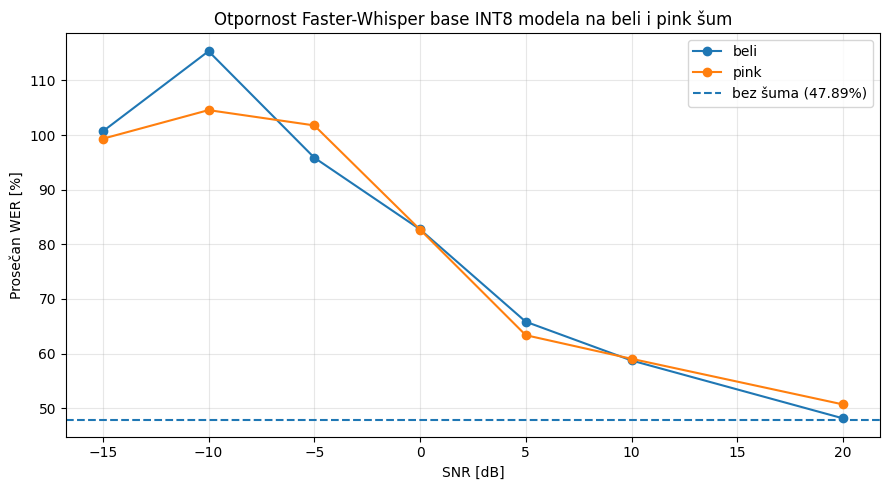

In [14]:
# ============================================================
# GRAFIK — SNR VS WER
# ============================================================

plt.figure(figsize=(9, 5))


for naziv_suma in [
    "beli",
    "pink"
]:

    podaci = tabela_pivot[
        [
            "SNR [dB]",
            naziv_suma
        ]
    ].dropna()


    plt.plot(
        podaci["SNR [dB]"],
        podaci[naziv_suma],
        marker="o",
        label=naziv_suma
    )


plt.axhline(
    clean_prosek,
    linestyle="--",
    label=f"bez šuma ({clean_prosek:.2f}%)"
)


plt.xlabel("SNR [dB]")
plt.ylabel("Prosečan WER [%]")

plt.title(
    "Otpornost Faster-Whisper base INT8 modela na beli i pink šum"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Komentar grafika

Grafik jasno pokazuje obrnuti odnos između SNR-a i greške transkripcije: sa smanjivanjem SNR vrednosti prosečan WER raste. Najveća degradacija uočava se pri prelasku ka **0 dB i negativnim SNR vrednostima**, kada šum postaje uporediv sa govorom ili ga nadjačava.

Krivе belog i pink šuma uglavnom prate sličan trend. Pri **0 dB** rezultati su gotovo identični, sa WER vrednostima od **82,74%** i **82,70%**. Na pojedinim SNR nivoima postoje veće razlike, kao pri **-10 dB**, gde beli šum daje WER od **115,34%**, a pink šum **104,56%**, ali rezultati ne pokazuju da je jedan tip šuma dosledno štetniji na svim nivoima.

Zbog toga se iz ovog eksperimenta može zaključiti da je **intenzitet šuma izraženiji i konzistentniji faktor degradacije od samog tipa šuma**, dok uticaj spektralnog tipa zavisi od konkretnog SNR nivoa i audio zapisa.


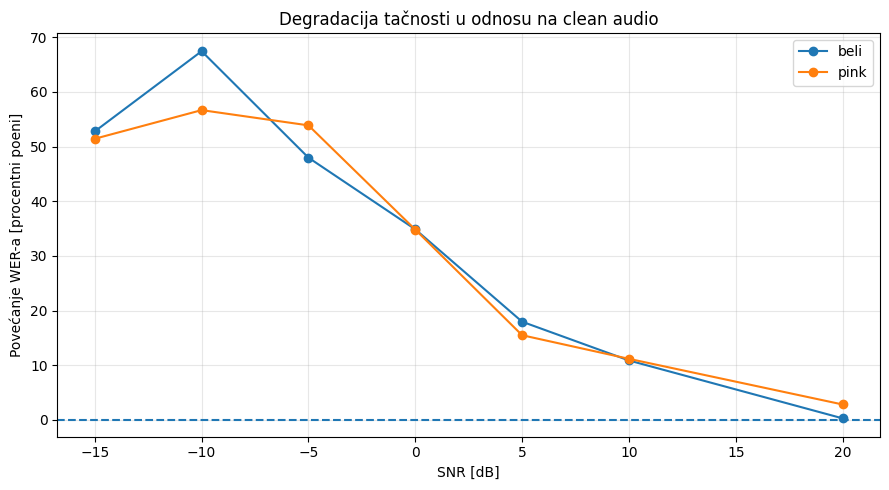

In [15]:
# ============================================================
# GRAFIK — POVEĆANJE WER-a U ODNOSU NA CLEAN SIGNAL
# ============================================================

plt.figure(figsize=(9, 5))


for naziv_suma in [
    "beli",
    "pink"
]:

    podaci = tabela_delta[
        tabela_delta["Tip šuma"] == naziv_suma
    ]


    plt.plot(
        podaci["SNR [dB]"],
        podaci["Delta WER [pp]"],
        marker="o",
        label=naziv_suma
    )


plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("SNR [dB]")
plt.ylabel("Povećanje WER-a [procentni poeni]")

plt.title(
    "Degradacija tačnosti u odnosu na clean audio"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Degradacija u odnosu na clean signal

Poređenje sa prosečnim clean WER-om od **47,89%** dodatno pokazuje koliko se kvalitet transkripcije pogoršava sa povećavanjem šuma.

Pri **20 dB** promena je mala: beli šum povećava prosečan WER za svega **0,27 procentnih poena**, a pink za **2,82 procentna poena**. Pri **10 dB** degradacija već iznosi približno **11 procentnih poena**, dok pri **5 dB** raste na približno **15–18 procentnih poena**.

Pri **0 dB** oba tipa šuma povećavaju WER za približno **35 procentnih poena** u odnosu na clean signal. U negativnom SNR području degradacija postaje veoma velika: pri **-5 dB** povećanje iznosi približno **48–54 procentna poena**, dok pri **-10 dB** dostiže približno **57–67 procentnih poena**.

Ovi rezultati ukazuju da Faster-Whisper `base` INT8 pokazuje određenu otpornost na slabiji pozadinski šum, ali kvalitet transkripcije naglo opada kada se odnos signal-šum približi 0 dB i pređe u negativno područje.


In [16]:
# ============================================================
# ZAVRŠNI REZIME EKSPERIMENTA 02
# ============================================================

print("=" * 90)
print("ZAVRŠNI REZULTATI — OTPORNOST NA ŠUM")
print("=" * 90)

print(f"Broj originalnih snimaka: {len(test_set)}")
print(f"Broj govornika: {tabela_snr['Govornik'].nunique()}")
print(f"Broj noisy fajlova: {len(generisani_fajlovi)}")
print(f"Ukupan broj transkripcija: {len(tabela_snr)}")

print(f"\nProsečan CLEAN WER: {clean_prosek:.2f}%")


for snr_db in snr_vrednosti:

    red = tabela_pivot[
        tabela_pivot["SNR [dB]"] == snr_db
    ]

    if len(red) == 0:
        continue

    beli = red["beli"].iloc[0]
    pink = red["pink"].iloc[0]

    print(
        f"SNR {snr_db:>3} dB | "
        f"beli WER: {beli:6.2f}% | "
        f"pink WER: {pink:6.2f}%"
    )

ZAVRŠNI REZULTATI — OTPORNOST NA ŠUM
Broj originalnih snimaka: 10
Broj govornika: 3
Broj noisy fajlova: 140
Ukupan broj transkripcija: 150

Prosečan CLEAN WER: 47.89%
SNR  20 dB | beli WER:  48.16% | pink WER:  50.71%
SNR  10 dB | beli WER:  58.75% | pink WER:  59.06%
SNR   5 dB | beli WER:  65.84% | pink WER:  63.38%
SNR   0 dB | beli WER:  82.74% | pink WER:  82.70%
SNR  -5 dB | beli WER:  95.86% | pink WER: 101.76%
SNR -10 dB | beli WER: 115.34% | pink WER: 104.56%
SNR -15 dB | beli WER: 100.67% | pink WER:  99.32%


In [17]:
# ============================================================
# ČUVANJE REZULTATA
# ============================================================

tabela_snr.to_csv(
    REZULTATI_DIR / "02_snr_svi_rezultati.csv",
    index=False,
    encoding="utf-8-sig"
)


tabela_prosek.to_csv(
    REZULTATI_DIR / "02_snr_rezime.csv",
    index=False,
    encoding="utf-8-sig"
)


tabela_pivot.to_csv(
    REZULTATI_DIR / "02_snr_pivot.csv",
    index=False,
    encoding="utf-8-sig"
)


tabela_delta.to_csv(
    REZULTATI_DIR / "02_snr_delta_wer.csv",
    index=False,
    encoding="utf-8-sig"
)


rezime_govornici.to_csv(
    REZULTATI_DIR / "02_snr_po_govorniku.csv",
    index=False,
    encoding="utf-8-sig"
)


rezime_duzine.to_csv(
    REZULTATI_DIR / "02_snr_po_duzini.csv",
    index=False,
    encoding="utf-8-sig"
)


print("\nRezultati su sačuvani u:")
print(REZULTATI_DIR)


Rezultati su sačuvani u:
D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\rezultati\02_otpornost_na_sum_snr


## O WER vrednostima većim od 100%

Kod veoma degradiranih audio zapisa zabeležene su i WER vrednosti veće od **100%**. Takav rezultat nije greška u izračunavanju metrike.

WER se određuje na osnovu broja zamena, brisanja i umetanja reči u odnosu na broj reči referentnog transkripta. Ako model, pored pogrešno prepoznatih ili izostavljenih reči, generiše veliki broj dodatnih reči koje ne postoje u referenci, ukupan broj grešaka može biti veći od broja referentnih reči, pa WER može preći 100%.

U ovom eksperimentu takve vrednosti pojavljuju se prvenstveno pri veoma niskim SNR nivoima i predstavljaju dodatni pokazatelj ozbiljne degradacije sposobnosti modela da prepozna govor u prisustvu dominantnog 
## Zaključak eksperimenta

Eksperiment je pokazao snažnu zavisnost kvaliteta Faster-Whisper transkripcije od odnosa signal-šum. Na clean audio zapisima prosečan WER iznosio je **47,89%**, dok dodavanje relativno slabog šuma pri **20 dB** nije izazvalo veliko dodatno pogoršanje.

Sa smanjivanjem SNR-a greška progresivno raste. Pri **10 dB** prosečan WER iznosi približno **59%**, pri **5 dB** oko **63–66%**, a pri **0 dB** približno **83%** za oba tipa šuma. U negativnom SNR području transkripcija postaje izrazito nepouzdana, sa prosečnim WER vrednostima približno ili čak iznad **100%**.

Beli i pink šum pokazuju sličan opšti trend degradacije. Nijedan tip šuma nije dosledno proizveo veći WER na svim SNR nivoima, što ukazuje da je u ovom eksperimentu nivo SNR-a imao jasniji i konzistentniji uticaj na kvalitet transkripcije od samog tipa šuma.

Rezultati potvrđuju da Faster-Whisper `base` INT8 može relativno dobro da zadrži početni nivo performansi pri slabijem šumu, ali njegova robusnost značajno opada kada šum postane približno jednak ili snažniji od govornog signala. Eksperiment time pokazuje značaj evaluacije ASR sistema u različitim akustičkim uslovima, jer rezultati dobijeni na čistom audio signalu nisu dovoljni za procenu ponašanja sistema u realnim bučnim okruženjima.
šuma.
